This notebook is used for:
- reproducing the results of Harman WRR 2024;
- and training differentiable SAS-based transport model.

In [2]:
import pandas as pd

import jax
import jax.numpy as jnp
import jax.tree_util as jtu

import equinox as eqx

import optax

from DiffFlowTransport.transport import SASTransport
from DiffFlowTransport.sas import SAS_Gamma, SAS_Uniform, SAS_Gamma_VaryingScale
from DiffFlowTransport.sas import SAS_NormalMDN, SAS_GammaMDN
from DiffFlowTransport.utils import compute_metrics, mse, train
from DiffFlowTransport.utils.plot import plot_timeseries_obs_1to1

import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2
# %reload_ext autoreload


# Read the data

In [3]:
df = pd.read_csv('./data.csv', index_col=1)
df.index = pd.to_datetime(df.index, format='%m/%d/%y')
df.head()

,timestep,J,Cl mg/l,Q,ET,Q Cl mg/l,S_scale
datetime,,,,,,,
1983-05-03,0,0.25,1.643836,3.404765,3.279204,NaN,4675.943543
1983-05-04,1,0.00,0.000000,3.032749,2.572585,NaN,4909.717786
1983-05-05,2,6.25,1.643836,2.954061,0.882162,NaN,4979.097380
1983-05-06,3,11.75,1.643836,3.821581,1.653902,NaN,4471.583891
1983-05-07,4,11.25,1.643836,5.064662,0.994315,NaN,3957.744963


In [4]:
J = jnp.array(df['J'].values)
Q = jnp.array(df['Q'].values)
ET = jnp.array(df['ET'].values)
C_J = jnp.array(df['Cl mg/l'].values)
C_Q_J = jnp.array(df['Q Cl mg/l'].values)

INFO:2025-01-31 16:56:56,768:jax._src.xla_bridge:945: Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
2025-01-31 16:56:56,768 - INFO - Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
INFO:2025-01-31 16:56:56,770:jax._src.xla_bridge:945: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/Users/jian449/anaconda3/envs/nn-flow-transport/bin/../lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file), '/usr/local/lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache)
2025-01-31 16:56:56,770 - INFO - Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volume

In [5]:
# import jax
# import jax.numpy as jnp
# jax.scipy.stats.uniform.cdf(1.1, scale=2.2)

# Running the SAS model (w/o training)

In [19]:
jnp.mean(C_J * J) / Q.mean()

Array(7.415516, dtype=float32)

In [6]:
# Parameters
params = {
    "dt": 1.,
    "α_Q": 1.,
    "α_ET": 0.,
    "k1": [0.],
    "C_eq": [0.],
    # "C_Q_old": [0.],
    # "C_Q_old": [jnp.mean(C_J * J) / Q.mean() / (1-0.26)]
    # "C_Q_old": [jnp.mean(C_J * J) / Q.mean()]
    "C_Q_old": [6.]
}

# Other arguments for running the model
nt = Q.size
sTmT_init = jnp.zeros([nt, 2])


In [7]:
df.head()

,timestep,J,Cl mg/l,Q,ET,Q Cl mg/l,S_scale
datetime,,,,,,,
1983-05-03,0,0.25,1.643836,3.404765,3.279204,NaN,4675.943543
1983-05-04,1,0.00,0.000000,3.032749,2.572585,NaN,4909.717786
1983-05-05,2,6.25,1.643836,2.954061,0.882162,NaN,4979.097380
1983-05-06,3,11.75,1.643836,3.821581,1.653902,NaN,4471.583891
1983-05-07,4,11.25,1.643836,5.064662,0.994315,NaN,3957.744963


## Invariant SAS functions
Assuming $\Omega_Q$ and $\Omega_{ET}$ are the gamma and uniform distributions, separately.

In [8]:
# SAS functions
sas_Q = SAS_Gamma(a=0.53, scale=8215.)
sas_ET = SAS_Uniform(scale=737.)

# SAS arguments 
sas_Q_args = Q[:,None]
sas_ET_args = ET[:,None]


In [9]:
# Initialize the SAS transport model
sas_transport = SASTransport(sas_Q, sas_ET, **params)

In [10]:
# Run the model
sT, mT, mQETs, pQETs, mRs, C_Q = sas_transport(
    J, C_J, Q, ET, sTmT_init, sas_Q_args, sas_ET_args
)
# plt.plot(C_Q)
df['C_Q InvariantGamma'] = C_Q


In [11]:
# sTmT_init2 = jnp.concat([sT[:,-1,None], mT[:,-1,:]], axis=-1)
# # Run the model
# sT, mT, mQETs, pQETs, mRs, C_Q = sas_transport(
#     J, C_J, Q, ET, sTmT_init2, sas_Q_args, sas_ET_args
# )
# df['C_Q 1b'] = C_Q

In [12]:
# Compute the metrics
compute_metrics(df['C_Q InvariantGamma'].values, df['Q Cl mg/l'].values, mask_naninf=True)


{'rse': 0.4892664960763935,
 'mare': 0.07978206144044103,
 'rmse': 0.8396291020571606,
 'mse': 0.7049770290213138,
 'r2': -0.09904803072368829,
 'kge': 0.5631965729742365,
 'nse': 0.5107335039236065,
 'mkge': 0.5659851833729854,
 'cc': 0.7171217934188919,
 'alpha': 0.9945313467319599,
 'beta': 0.6708816700263096}

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(8,5))
ax.plot(df['C_Q InvariantGamma']["1994":"1997"], label='Simulation')
ax.plot(df['Q Cl mg/l']["1994":"1997"], 'k.', markersize=2, label='True')
ax.set(ylim=[4, 10], title='Cl concentration ($\Omega_Q$: Gamma; $\Omega_{ET}$: Uniform)', 
       ylabel='[mg/l]')
ax.legend()

fig, ax = plt.subplots(1, 1, figsize=(8,5))
ax.plot(df['C_Q InvariantGamma'], label='Simulation')
ax.plot(df['Q Cl mg/l'], 'k.', markersize=2, label='True')
ax.set(ylim=[0, 15], title='Cl concentration ($\Omega_Q$: Gamma; $\Omega_{ET}$: Uniform)', 
       ylabel='[mg/l]')
ax.legend()


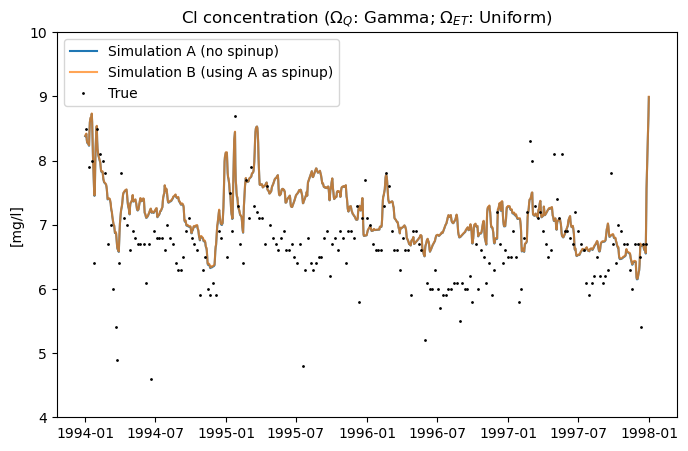

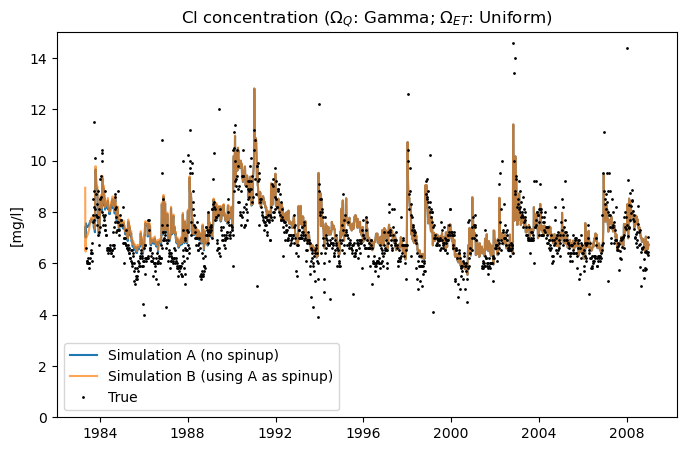

In [12]:
# fig, ax = plt.subplots(1, 1, figsize=(8,5))
# ax.plot(df['C_Q 1']["1994":"1997"], label='Simulation A (no spinup)')
# ax.plot(df['C_Q 1b']["1994":"1997"], alpha=0.7, label='Simulation B (using A as spinup)')
# ax.plot(df['Q Cl mg/l']["1994":"1997"], 'k.', markersize=2, label='True')
# ax.set(ylim=[4, 10], title='Cl concentration ($\Omega_Q$: Gamma; $\Omega_{ET}$: Uniform)', 
#        ylabel='[mg/l]')
# ax.legend()

# fig, ax = plt.subplots(1, 1, figsize=(8,5))
# ax.plot(df['C_Q 1'], label='Simulation A (no spinup)')
# ax.plot(df['C_Q 1b'], alpha=0.7, label='Simulation B (using A as spinup)')
# ax.plot(df['Q Cl mg/l'], 'k.', markersize=2, label='True')
# ax.set(ylim=[0, 15], title='Cl concentration ($\Omega_Q$: Gamma; $\Omega_{ET}$: Uniform)', 
#        ylabel='[mg/l]')
# ax.legend()


## Storage dependent SAS

In [13]:
# SAS functions
sas_Q = SAS_Gamma_VaryingScale(a=0.69, scale=8215.)
sas_ET = SAS_Uniform(scale=398.)

# SAS arguments 
# sas_Q_args = jnp.array(df['S_scale'].values[:,None])
sas_Q_args = jnp.array(df['S_scale'].values)
sas_ET_args = ET


In [14]:
# Initialize the SAS transport model
sas_transport2 = SASTransport(sas_Q, sas_ET, **params)

In [15]:
# Run the model
sT, mT, mQETs, pQETs, mRs, C_Q = sas_transport2(
    J, C_J, Q, ET, sTmT_init, sas_Q_args, sas_ET_args
)
# plt.plot(C_Q)
df['C_Q 2'] = C_Q

In [16]:
# Rerun the model
sTmT_init2 = jnp.concat([sT[:,-1,None], mT[:,-1,:]], axis=-1)
sT, mT, mQETs, pQETs, mRs, C_Q = sas_transport2(
    J, C_J, Q, ET, sTmT_init2, sas_Q_args, sas_ET_args
)
df['C_Q 2b'] = C_Q

In [11]:
# Compute the metrics
compute_metrics(df['C_Q 2'].values, df['Q Cl mg/l'].values, mask_naninf=True)


{'rse': 0.5941610177368719,
 'mare': 0.10363730369511906,
 'rmse': 0.9252664646301679,
 'mse': 0.8561180305692098,
 'r2': -0.013129741459650734,
 'kge': 0.6412300801390027,
 'nse': 0.4058389822631281,
 'mkge': 0.6105174285166288,
 'cc': 0.7354019538188645,
 'alpha': 1.0621091830080627,
 'beta': 0.7210250964109925}

In [18]:
df.keys()

Index(['timestep', 'J', 'Cl mg/l', 'Q', 'ET', 'Q Cl mg/l', 'S_scale', 'C_Q 2',
       'C_Q 2b', 'C_Q InvariantGamma'],
      dtype='object')

(<Figure size 1500x400 with 2 Axes>,
 <Axes: title={'center': 'Cl ($\\Omega_Q$: Storage-dependent Gamma; $\\Omega_{ET}$: Invariant Uniform)'}, xlabel='Time '>,
 <Axes: title={'center': ' (RMSE: 0.754; NSE: 0.606)'}, xlabel='Observation', ylabel='Simulation'>)

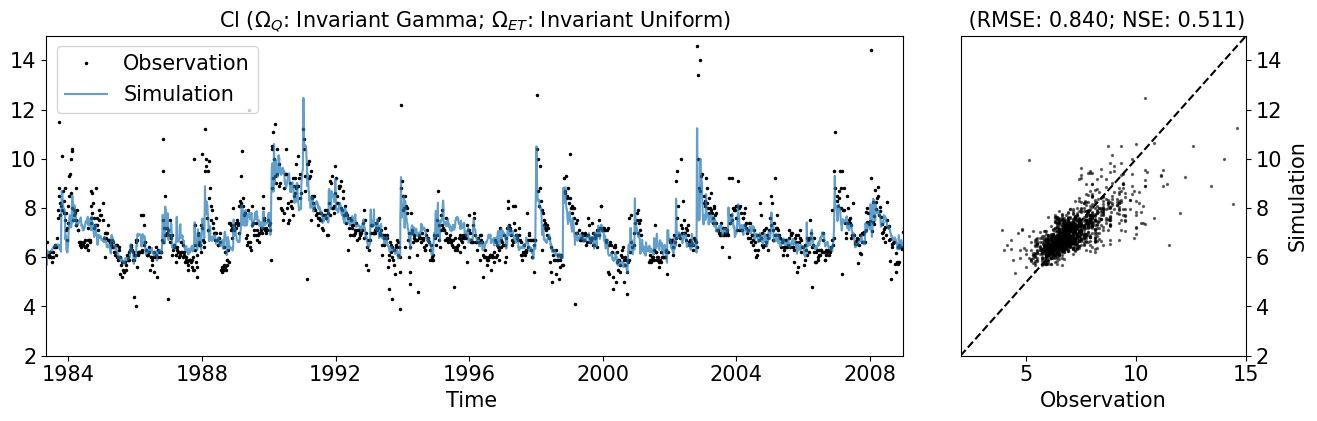

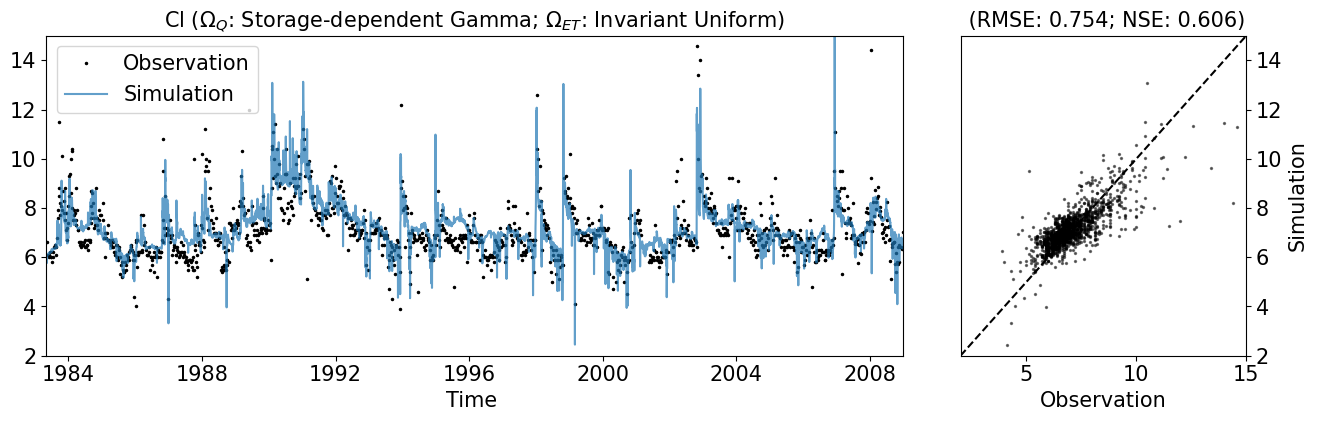

In [17]:
# fig, ax = plt.subplots(1, 1, figsize=(8,5))
# ax.plot(df['C_Q 2'], label='Simulation')
# ax.plot(df['C_Q InvariantGamma'], alpha=0.7, label='Simulation B (using A as spinup)')
# ax.plot(df['Q Cl mg/l'], 'k.', markersize=2, label='True')
# ax.set(ylim=[0, 15], title='Cl concentration ($\Omega_Q$: Gamma; $\Omega_{ET}$: Uniform)', 
#        ylabel='[mg/l]')
# ax.legend()

plot_timeseries_obs_1to1(
    obs=df['Q Cl mg/l'].values, sim=df['C_Q InvariantGamma'].values, lim=[2,15], 
    timesteps=df.index,
    varn='Cl ($\Omega_Q$: Invariant Gamma; $\Omega_{ET}$: Invariant Uniform)'
)

plot_timeseries_obs_1to1(
    obs=df['Q Cl mg/l'].values, sim=df['C_Q 2'].values, lim=[2,15], 
    timesteps=df.index,
    varn='Cl ($\Omega_Q$: Storage-dependent Gamma; $\Omega_{ET}$: Invariant Uniform)'
)


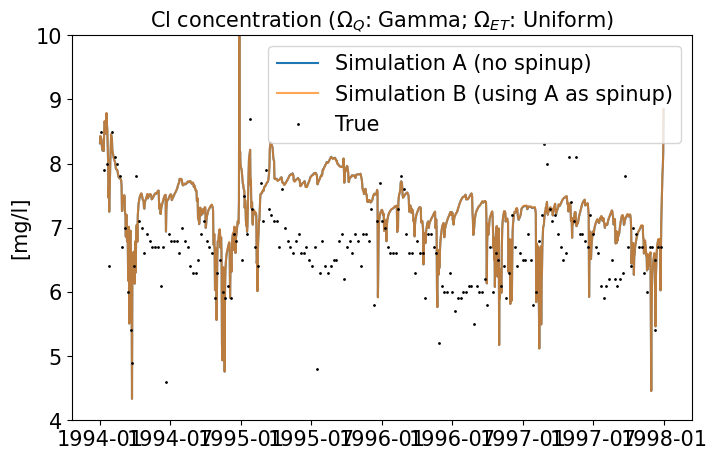

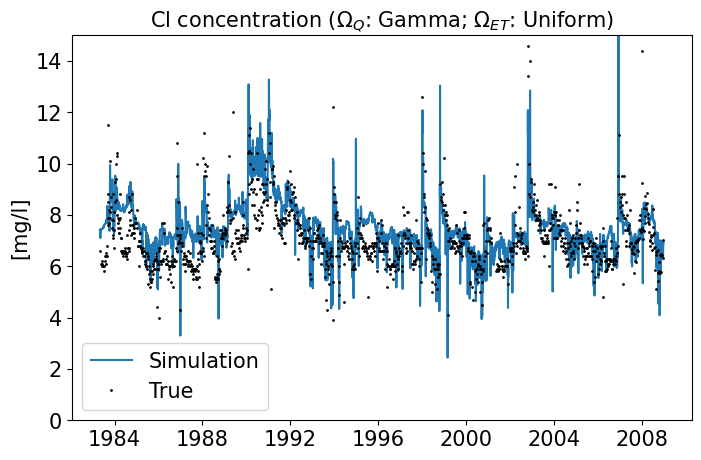

In [ ]:
# fig, ax = plt.subplots(1, 1, figsize=(8,5))
# ax.plot(df['C_Q 2']["1994":"1997"], label='Simulation A (no spinup)')
# ax.plot(df['C_Q 2b']["1994":"1997"], alpha=0.7, label='Simulation B (using A as spinup)')
# ax.plot(df['Q Cl mg/l']["1994":"1997"], 'k.', markersize=2, label='True')
# ax.set(ylim=[4, 10], title='Cl concentration ($\Omega_Q$: Gamma; $\Omega_{ET}$: Uniform)', 
#        ylabel='[mg/l]')
# ax.legend()


# fig, ax = plt.subplots(1, 1, figsize=(8,5))
# ax.plot(df['C_Q 2'], label='Simulation')
# # ax.plot(df['C_Q 2'], label='Simulation A (no spinup)')
# # ax.plot(df['C_Q 2b'], alpha=0.7, label='Simulation B (using A as spinup)')
# ax.plot(df['Q Cl mg/l'], 'k.', markersize=2, label='True')
# ax.set(ylim=[0, 15], title='Cl concentration ($\Omega_Q$: Gamma; $\Omega_{ET}$: Uniform)', 
#        ylabel='[mg/l]')
# ax.legend()


## MDN-based SAS

In [149]:
# SAS functions
n_input, n_hidden, n_mixture, key = 1, 20, 5, jax.random.key(42)
mlp_kwargs = {"width_size": 20, "depth":3}
sas_Q = SAS_MDN(n_input, n_hidden, n_mixture, key, scale=8215, **mlp_kwargs)
sas_ET = SAS_Uniform(scale=737.)

# SAS arguments 
sas_Q_args = Q[:,None]
sas_ET_args = ET[:,None]


In [66]:
# Initialize the SAS transport model
sas_transport2 = SASTransport(sas_Q, sas_ET, **params)

In [68]:
# Spinup the model
sT, mT, mQETs, pQETs, mRs, C_Q = sas_transport2(
    J, C_J, Q, ET, sTmT_init, sas_Q_args, sas_ET_args
)
# plt.plot(C_Q)
df['C_Q 2'] = C_Q

In [69]:
# Rerun the model
sTmT_init2 = jnp.concat([sT[:,-1,None], mT[:,-1,:]], axis=-1)
sT, mT, mQETs, pQETs, mRs, C_Q = sas_transport2(
    J, C_J, Q, ET, sTmT_init2, sas_Q_args, sas_ET_args
)
df['C_Q 2b'] = C_Q

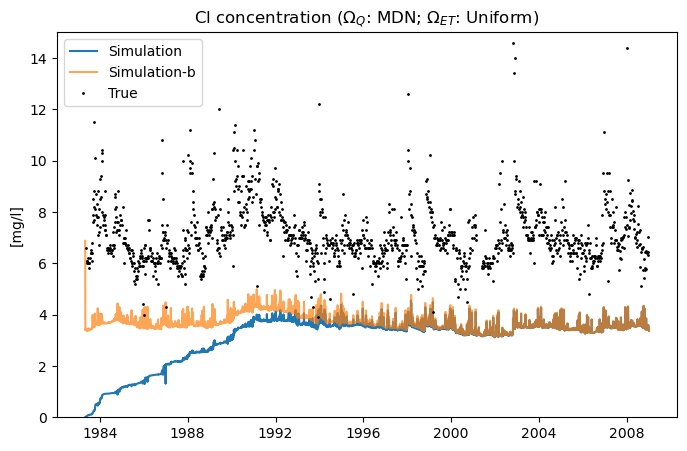

In [70]:
fig, ax = plt.subplots(1, 1, figsize=(8,5))
ax.plot(df['C_Q 2'], label='Simulation')
ax.plot(df['C_Q 2b'], alpha=0.7, label='Simulation-b')
ax.plot(df['Q Cl mg/l'], 'k.', markersize=2, label='True')
ax.set(ylim=[0, 15], title='Cl concentration ($\Omega_Q$: MDN; $\Omega_{ET}$: Uniform)', 
       ylabel='[mg/l]')
ax.legend()


# Training the SAS-based transport model

In [7]:
# Training parameters
epochs = 100
loss_func = mse
optim = optax.adam(learning_rate=0.01)

In [8]:
# Separate training and test sets
start_train, end_train = '1989-01-01', '1998-12-31'
start_test, end_test = '1999-01-01', '2008-12-31'

start_train_ind = df.index.get_loc(start_train)
end_train_ind = df.index.get_loc(end_train)
start_test_ind = df.index.get_loc(start_test)
end_test_ind = df.index.get_loc(end_test)


## Invariant SAS functions

In [8]:
# SAS functions
sas_Q = SAS_Gamma(a=0.53, scale=8215.)
sas_ET = SAS_Uniform(scale=737.)

# SAS arguments 
sas_Q_args = Q[:,None]
sas_ET_args = ET[:,None]

# Initialize the SAS transport model
model = SASTransport(sas_Q, sas_ET, **params)


In [9]:
filter_model_spec = jtu.tree_map(lambda _: False, model)
sas_Q_filter = jtu.tree_map(lambda _: True, sas_Q)
sas_ET_filter = jtu.tree_map(lambda _: True, sas_ET)
sas_Q_filter = eqx.tree_at(lambda t: (t.loc,), sas_Q_filter, replace=(False,))
sas_ET_filter = eqx.tree_at(lambda t: (t.loc,), sas_ET_filter, replace=(False,))
filter_model_spec = eqx.tree_at(lambda t: (t.sas_Q, t.sas_ET), filter_model_spec, replace=(sas_Q_filter, sas_ET_filter))


In [10]:
# Inputs and outputs
mask = jnp.where(~jnp.isnan(C_Q_J))
x = [J, C_J, Q, ET, sTmT_init, sas_Q_args, sas_ET_args, mask]
y = C_Q_J[mask][:,None]

# Traing data
# During training, we run the model until the end of the training period
mask_train = mask[0][(mask[0]>start_train_ind) & (mask[0]<end_train_ind)]
# x_train = [J[:end_train_ind], C_J[:end_train_ind], Q[:end_train_ind], ET[:end_train_ind], 
#            sTmT_init[:end_train_ind], sas_Q_args[:end_train_ind], sas_ET_args[:end_train_ind], mask_train]
x_train = [e[:end_train_ind] for e in x[:-1]] + [mask_train]
y_train = C_Q_J[mask_train][:,None]

# Test data
# During test, we run the model throughout the whole period but evaluate only on the test period
mask_test = mask[0][(mask[0]>start_test_ind) & (mask[0]<end_test_ind)]
x_test = [J, C_J, Q, ET, sTmT_init, sas_Q_args, sas_ET_args, mask_test]
y_test = C_Q_J[mask_test][:,None]

y_train.shape, y_test.shape


((520, 1), (492, 1))

In [12]:
model_new, loss_train, loss_test = train(
    model.get_CQ, filter_model_spec.get_CQ,
    epochs, loss_func, optim, x_train, y_train, x_test, y_test
)


100%|██████████| 10/10 [13:04<00:00, 78.47s/it]


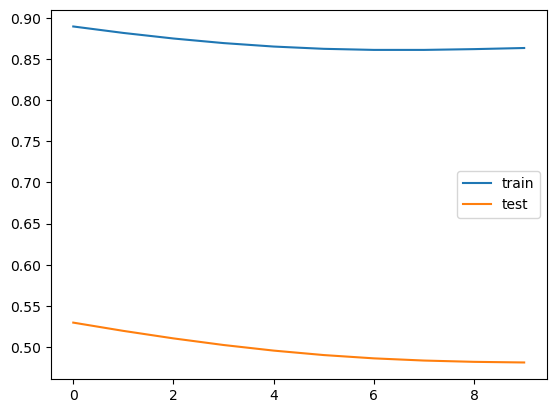

In [26]:
# Plot the loss
plt.plot(loss_train, label='train')
plt.plot(loss_test, label='test')
plt.legend()

In [13]:
# Run the trained model
model_new = model_new.__self__
sT, mT, mQETs, pQETs, mRs, C_Q = model_new(
    J, C_J, Q, ET, sTmT_init, sas_Q_args, sas_ET_args
)
# plt.plot(C_Q)
df['C_Q 1-trained'] = C_Q

# Run the untrained model
sT, mT, mQETs, pQETs, mRs, C_Q = model(
    J, C_J, Q, ET, sTmT_init, sas_Q_args, sas_ET_args
)
# plt.plot(C_Q)
df['C_Q 1'] = C_Q


In [20]:
# metrics = compute_metrics(df['C_Q 1-trained'].values, df['Q Cl mg/l'].values, mask_naninf=True)


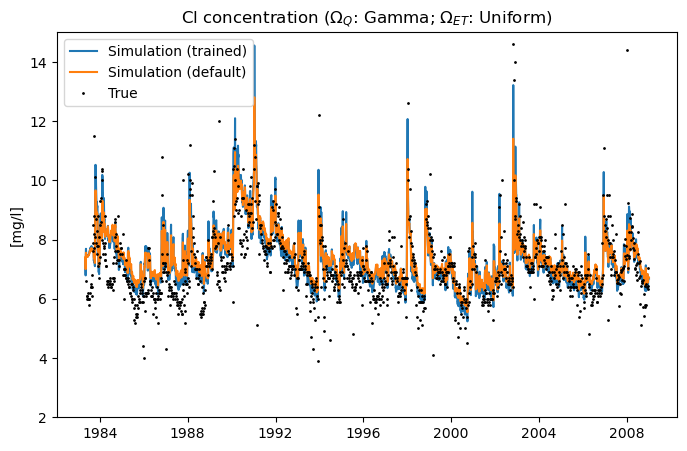

In [17]:
# fig, ax = plt.subplots(1, 1, figsize=(8,5))
# ax.plot(df['C_Q 1-trained']["1994":"1997"], label='Simulation A (no spinup)')
# ax.plot(df['Q Cl mg/l']["1994":"1997"], 'k.', markersize=2, label='True')
# ax.set(ylim=[4, 10], title='Cl concentration ($\Omega_Q$: Gamma; $\Omega_{ET}$: Uniform)', 
#        ylabel='[mg/l]')
# ax.legend()

fig, ax = plt.subplots(1, 1, figsize=(8,5))
ax.plot(df['C_Q 1-trained'], label='Simulation (trained)')
ax.plot(df['C_Q 1'], label='Simulation (default)')
ax.plot(df['Q Cl mg/l'], 'k.', markersize=2, label='True')
ax.set(ylim=[2, 15], title='Cl concentration ($\Omega_Q$: Gamma; $\Omega_{ET}$: Uniform)', 
       ylabel='[mg/l]')
ax.legend()


## MDN Gaussian-based SAS

In [11]:
# SAS functions
n_input, n_hidden, n_mixture, key = 1, 10, 5, jax.random.key(42)
mlp_kwargs = {"width_size": 10, "depth":2}
sas_Q = SAS_NormalMDN(n_input, n_hidden, n_mixture, key, scale=8215., **mlp_kwargs)
sas_ET = SAS_Uniform(scale=737.)

# SAS arguments 
sas_Q_args = Q[:,None]
sas_ET_args = ET[:,None]

# Initialize the SAS transport model
model_mdn = SASTransport(sas_Q, sas_ET, **params)


In [12]:
filter_model_spec = jtu.tree_map(lambda _: False, model_mdn)
sas_Q_filter = jtu.tree_map(lambda _: True, sas_Q)
sas_ET_filter = jtu.tree_map(lambda _: True, sas_ET)
# sas_Q_filter = eqx.tree_at(lambda t: (t.loc,), sas_Q_filter, replace=(False,))
sas_ET_filter = eqx.tree_at(lambda t: (t.loc,), sas_ET_filter, replace=(False,))
filter_model_spec = eqx.tree_at(lambda t: (t.sas_Q, t.sas_ET), filter_model_spec, replace=(sas_Q_filter, sas_ET_filter))


In [13]:
# Inputs and outputs
mask = jnp.where(~jnp.isnan(C_Q_J))
x = [J, C_J, Q, ET, sTmT_init, sas_Q_args, sas_ET_args, mask]
y = C_Q_J[mask][:,None]

# Traing data
# During training, we run the model until the end of the training period
mask_train = mask[0][(mask[0]>start_train_ind) & (mask[0]<end_train_ind)]
# x_train = [J[:end_train_ind], C_J[:end_train_ind], Q[:end_train_ind], ET[:end_train_ind], 
#            sTmT_init[:end_train_ind], sas_Q_args[:end_train_ind], sas_ET_args[:end_train_ind], mask_train]
x_train = [e[:end_train_ind] for e in x[:-1]] + [mask_train]
y_train = C_Q_J[mask_train][:,None]

# Test data
# During test, we run the model throughout the whole period but evaluate only on the test period
mask_test = mask[0][(mask[0]>start_test_ind) & (mask[0]<end_test_ind)]
x_test = [J, C_J, Q, ET, sTmT_init, sas_Q_args, sas_ET_args, mask_test]
y_test = C_Q_J[mask_test][:,None]

y_train.shape, y_test.shape


((520, 1), (492, 1))

In [14]:
# Train the model
jax.clear_caches()
model_mdn_new, loss_train_mdn, loss_test_mdn = train(
    model_mdn.get_CQ, filter_model_spec.get_CQ,
    epochs, loss_func, optim, x_train, y_train, x_test, y_test
)
model_mdn_new = model_mdn_new.__self__


100%|██████████| 100/100 [13:22<00:00,  8.02s/it]


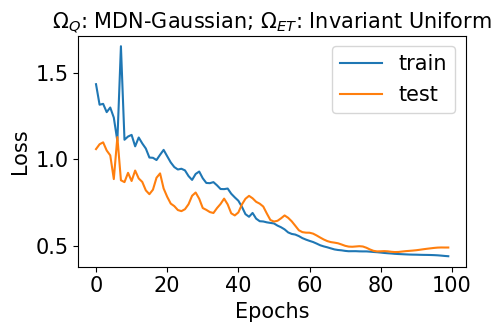

In [27]:
# Plot the loss
fig, ax = plt.subplots(1, 1, figsize=(5,3))
ax.plot(loss_train_mdn, label='train')
ax.plot(loss_test_mdn, label='test')
ax.set(xlabel='Epochs', ylabel='Loss', 
       title='$\Omega_Q$: MDN-Gaussian; $\Omega_{ET}$: Invariant Uniform')
ax.legend()

In [33]:
# Run the trained model
# 
sT, mT, mQETs, pQETs, mRs, C_Q = model_mdn_new(
    J, C_J, Q, ET, sTmT_init, sas_Q_args, sas_ET_args
)
# plt.plot(C_Q)
df['C_Q mdn-trained'] = C_Q

# # Run the untrained model
# sT, mT, mQETs, pQETs, mRs, C_Q = model_mdn(
#     J, C_J, Q, ET, sTmT_init, sas_Q_args, sas_ET_args
# )
# # plt.plot(C_Q)
# df['C_Q mdn'] = C_Q


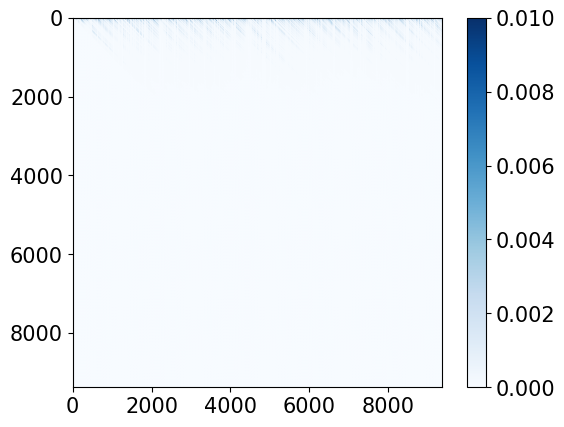

In [46]:
plt.imshow(pQETs[...,0], cmap='Blues', vmin=0., vmax=0.01)
plt.colorbar()
# plt.plot(pQETs[:,900,0])
# plt.imshow(sT, cmap='Blues')
# plt.colorbar()

In [17]:
# Compute the metrics
compute_metrics(df['C_Q mdn-trained'].values, df['Q Cl mg/l'].values, mask_naninf=True)


{'rse': 0.3915953680146483,
 'mare': 0.07656213995395376,
 'rmse': 0.7511618407517543,
 'mse': 0.5642441110015639,
 'r2': 0.2346637665556789,
 'kge': 0.6460521318558475,
 'nse': 0.6084046319853518,
 'mkge': 0.6360433778828802,
 'cc': 0.7904279901609984,
 'alpha': 1.0175707719310392,
 'beta': 0.7029557887305448}

(<Figure size 1500x400 with 2 Axes>,
 <Axes: title={'center': 'Cl ($\\Omega_Q$: Invariant Gamma; $\\Omega_{ET}$: Invariant Uniform)'}, xlabel='Time '>,
 <Axes: title={'center': ' (RMSE: 0.907; NSE: 0.429)'}, xlabel='Observation', ylabel='Simulation'>)

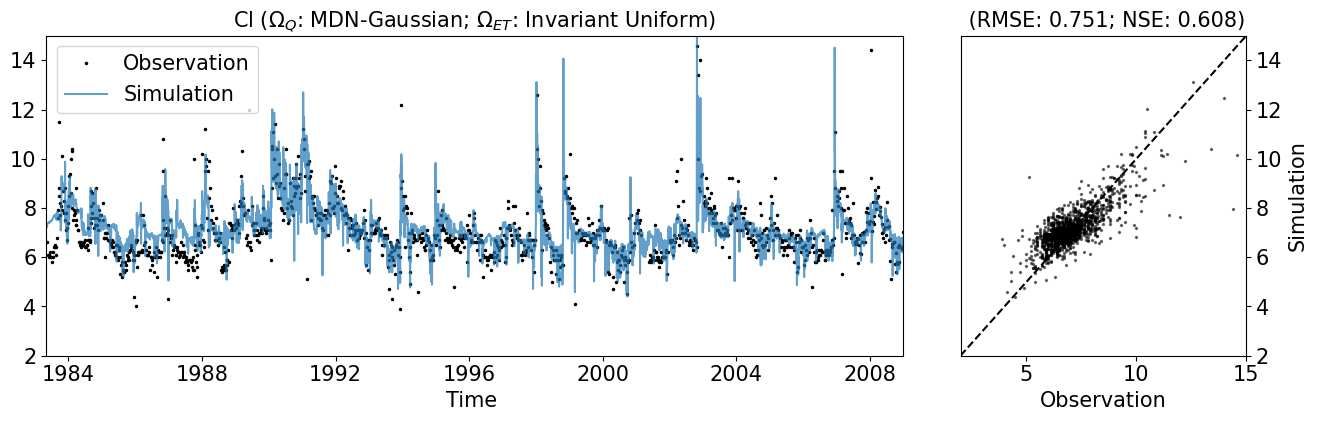

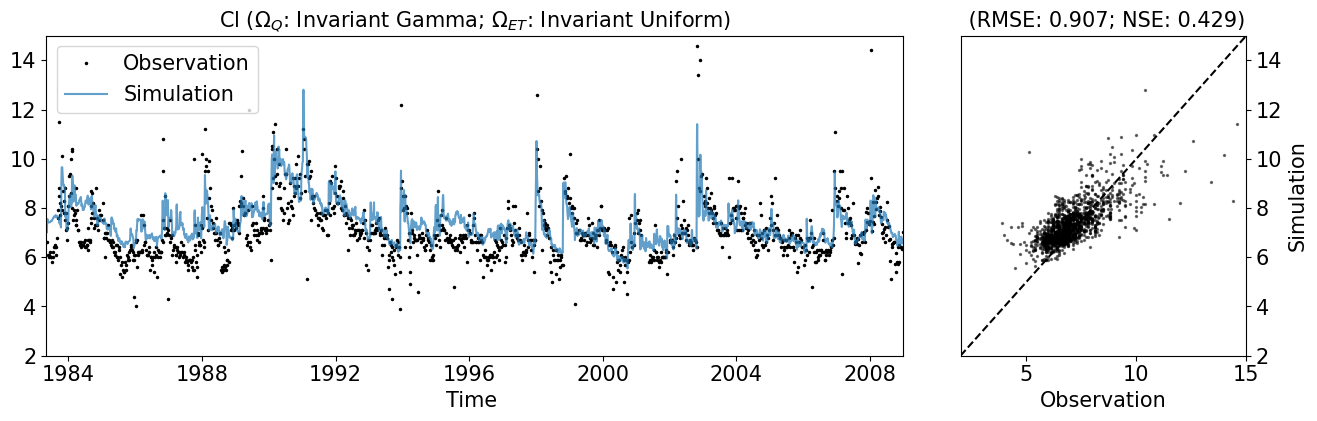

In [25]:
plot_timeseries_obs_1to1(
    obs=df['Q Cl mg/l'].values, sim=df['C_Q mdn-trained'].values, lim=[2,15], timesteps=df.index,
    varn='Cl ($\Omega_Q$: MDN-Gaussian; $\Omega_{ET}$: Invariant Uniform)'
)

plot_timeseries_obs_1to1(
    obs=df['Q Cl mg/l'].values, sim=df['C_Q InvariantGamma'].values, lim=[2,15], timesteps=df.index,
    varn='Cl ($\Omega_Q$: Invariant Gamma; $\Omega_{ET}$: Invariant Uniform)'
)


(<Figure size 1500x400 with 2 Axes>,
 <Axes: title={'center': 'Cl ($\\Omega_Q$: Invariant Gamma; $\\Omega_{ET}$: Invariant Uniform)'}, xlabel='Time '>,
 <Axes: title={'center': ' (RMSE: 1.021; NSE: 0.308)'}, xlabel='Observation', ylabel='Simulation'>)

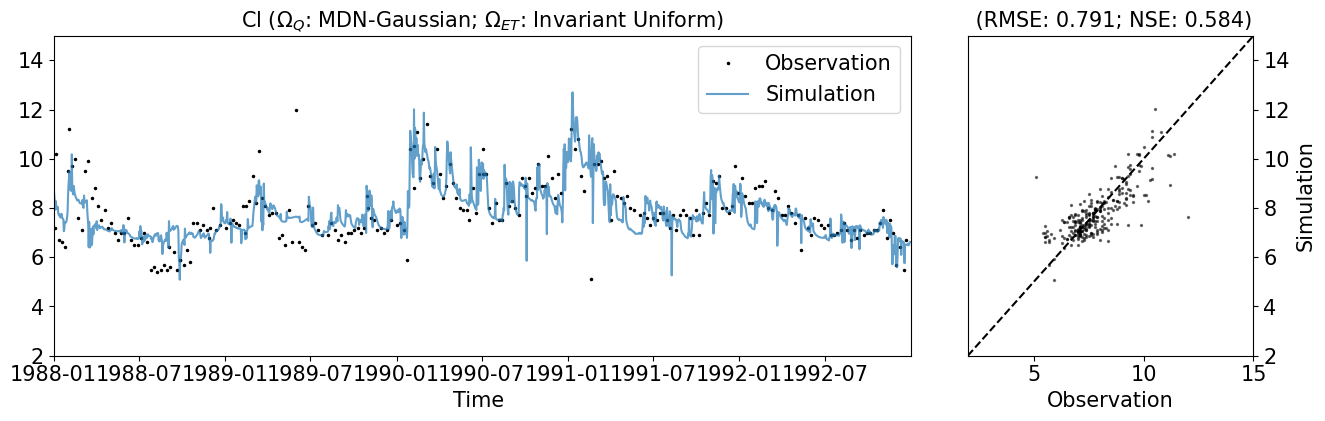

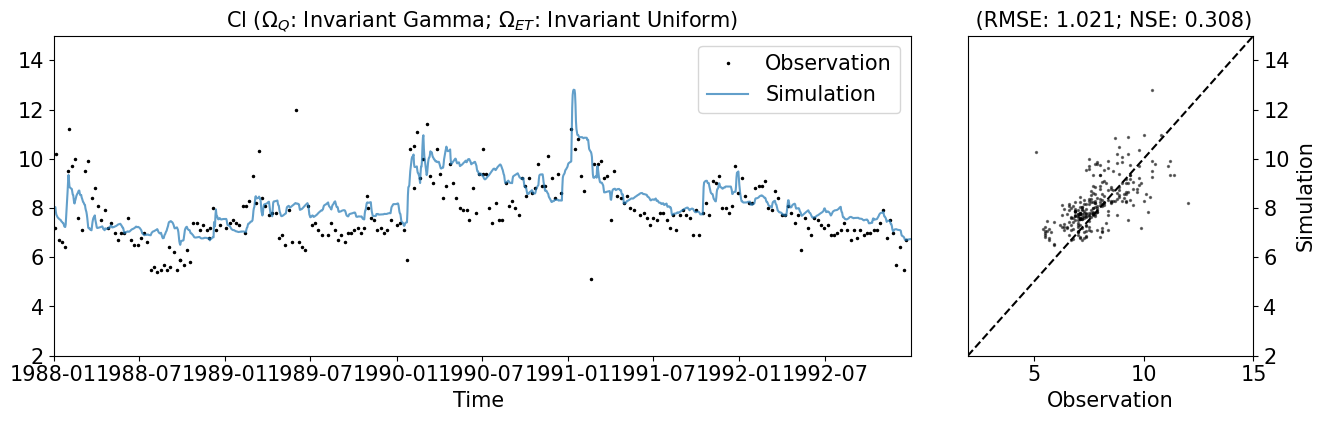

In [28]:
s, e = '1988', '1992'
plot_timeseries_obs_1to1(
    obs=df['Q Cl mg/l'][s:e].values, sim=df['C_Q mdn-trained'][s:e].values, lim=[2,15], 
    timesteps=df[s:e].index,
    varn='Cl ($\Omega_Q$: MDN-Gaussian; $\Omega_{ET}$: Invariant Uniform)'
)

plot_timeseries_obs_1to1(
    obs=df['Q Cl mg/l'][s:e].values, sim=df['C_Q InvariantGamma'][s:e].values, lim=[2,15], 
    timesteps=df[s:e].index,
    varn='Cl ($\Omega_Q$: Invariant Gamma; $\Omega_{ET}$: Invariant Uniform)'
)


## MDN Gamma-based SAS

In [9]:
# SAS functions
n_input, n_hidden, n_mixture, key = 1, 10, 5, jax.random.key(42)
mlp_kwargs = {"width_size": 10, "depth":2}
sas_Q = SAS_GammaMDN(n_input, n_hidden, n_mixture, key, scale=8215., **mlp_kwargs)
sas_ET = SAS_Uniform(scale=737.)

# SAS arguments 
sas_Q_args = Q[:,None]
sas_ET_args = ET[:,None]

# Initialize the SAS transport model
model_mdn_gamma = SASTransport(sas_Q, sas_ET, **params)


In [10]:
filter_model_spec = jtu.tree_map(lambda _: False, model_mdn_gamma)
sas_Q_filter = jtu.tree_map(lambda _: True, sas_Q)
sas_ET_filter = jtu.tree_map(lambda _: True, sas_ET)
# sas_Q_filter = eqx.tree_at(lambda t: (t.loc,), sas_Q_filter, replace=(False,))
sas_ET_filter = eqx.tree_at(lambda t: (t.loc,), sas_ET_filter, replace=(False,))
filter_model_spec = eqx.tree_at(lambda t: (t.sas_Q, t.sas_ET), filter_model_spec, replace=(sas_Q_filter, sas_ET_filter))


In [11]:
# Inputs and outputs
mask = jnp.where(~jnp.isnan(C_Q_J))
x = [J, C_J, Q, ET, sTmT_init, sas_Q_args, sas_ET_args, mask]
y = C_Q_J[mask][:,None]

# Traing data
# During training, we run the model until the end of the training period
mask_train = mask[0][(mask[0]>start_train_ind) & (mask[0]<end_train_ind)]
# x_train = [J[:end_train_ind], C_J[:end_train_ind], Q[:end_train_ind], ET[:end_train_ind], 
#            sTmT_init[:end_train_ind], sas_Q_args[:end_train_ind], sas_ET_args[:end_train_ind], mask_train]
x_train = [e[:end_train_ind] for e in x[:-1]] + [mask_train]
y_train = C_Q_J[mask_train][:,None]

# Test data
# During test, we run the model throughout the whole period but evaluate only on the test period
mask_test = mask[0][(mask[0]>start_test_ind) & (mask[0]<end_test_ind)]
x_test = [J, C_J, Q, ET, sTmT_init, sas_Q_args, sas_ET_args, mask_test]
y_test = C_Q_J[mask_test][:,None]

y_train.shape, y_test.shape


((520, 1), (492, 1))

In [ ]:
# Train the model
jax.clear_caches()
model_mdn_gamma_new, loss_train_mdn_gamma, loss_test_mdn_gamma = train(
    model_mdn_gamma.get_CQ, filter_model_spec.get_CQ,
    epochs, loss_func, optim, x_train, y_train, x_test, y_test
)


 22%|██▏       | 22/100 [6:14:43<25:54:19, 1195.64s/it]2025-01-27 16:20:43,960 - INFO - The loss of step 22: 0.6786671876907349


In [ ]:
# Plot the loss
fig, ax = plt.subplots(1, 1, figsize=(5,3))
ax.plot(loss_train_mdn, label='train')
ax.plot(loss_test_mdn, label='test')
ax.set(xlabel='Epochs', ylabel='Loss', 
       title='$\Omega_Q$: MDN-Gaussian; $\Omega_{ET}$: Invariant Uniform')
ax.legend()
